In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from theoretical_advection_experiment import get_all_data

/home/koehler/miniconda3/envs/emu-sup-paper-supplemental/lib/python3.12/site-packages/trainax/_general_trainer.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
configs = [
    {
        "network": "pure;2;relu",
        "gamma_1": 0.3,
        "train_simulator": "fd;1.0;1",
        "train_ic_distribution": train_ic_distribution,
        "test_ic_distribution": "ind;5;True",
        "seed_init": 0,
        "seed_train": 1,
        "seed_test": 2,
        "seed_shuffle": 3,
        "num_unrolled_steps": 1,
    }
    for train_ic_distribution in [
        "ind;1;True",
        "ind;1,2;True",
        "ind;1,2,3;True",
        "ind;1,2,3,4;True",
        "ind;1,2,3,4,5;True",
        "ind;1,2,3,4,5,6;True",
        "ind;1,2,3,4,5,6,7;True",
        # "ind;1,2,3,4,5,6,7,8;True",
        # "ind;1,2,3,4,5,6,7,8,9;True",
        # "ind;1,2,3,4,5,6,7,8,9,10;True",
        # All modes up to 10
        "fourier;10;True;True",
        # All modes up to 20
        "fourier;20;True;True",
        # All modes up to 30
        "fourier;30;True;True",
        # All modes up to 40
        "fourier;40;True;True",
        # All modes up to 50
        "fourier;50;True;True",
        ### More combinations
        "ind;4,6;True",
        "ind;3,4;True",
    ]
]

In [3]:
len(configs)

14

In [4]:
metrics, losses = get_all_data(configs)

100%|██████████| 14/14 [00:00<00:00, 138.96it/s]


In [5]:
metrics = pd.concat(metrics).reset_index(drop=True)
losses = pd.concat(losses).reset_index(drop=True)

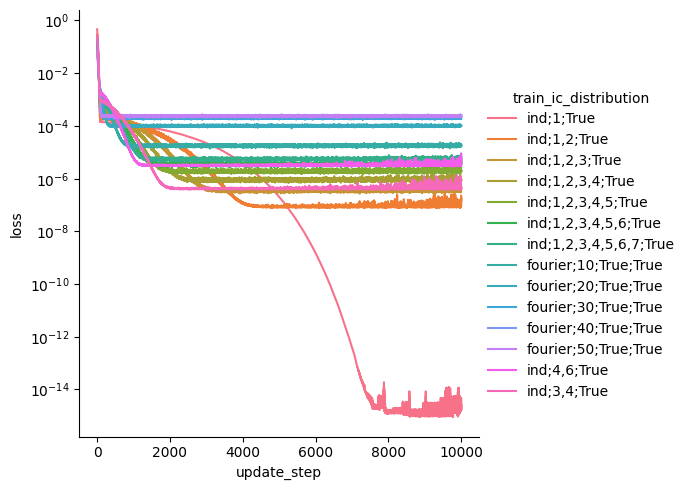

In [6]:
facet = sns.relplot(
    data=losses,
    x="update_step",
    y="loss",
    # col="setting",
    kind="line",
    hue="train_ic_distribution",
    estimator="median",
    errorbar=("pi", 50),
)

for ax in facet.axes.flat:
    ax.set_yscale("log")

In [7]:
metrics.query("time_step == 1")

,network,gamma_1,train_simulator,train_ic_distribution,test_ic_distribution,num_unrolled_steps,seed_init,seed_train,seed_test,seed_shuffle,superiority,error,time_step
0,pure;2;relu,0.3,fd;1.0;1,ind;1;True,ind;5;True,1,0,1,2,3,0.568084,0.007593,1
100,pure;2;relu,0.3,fd;1.0;1,"ind;1,2;True",ind;5;True,1,0,1,2,3,0.612017,0.008181,1
200,pure;2;relu,0.3,fd;1.0;1,"ind;1,2,3;True",ind;5;True,1,0,1,2,3,0.635609,0.008496,1
300,pure;2;relu,0.3,fd;1.0;1,"ind;1,2,3,4;True",ind;5;True,1,0,1,2,3,0.719470,0.009617,1
400,pure;2;relu,0.3,fd;1.0;1,"ind;1,2,3,4,5;True",ind;5;True,1,0,1,2,3,0.812942,0.010866,1
500,pure;2;relu,0.3,fd;1.0;1,"ind;1,2,3,4,5,6;True",ind;5;True,1,0,1,2,3,0.874815,0.011693,1
600,pure;2;relu,0.3,fd;1.0;1,"ind;1,2,3,4,5,6,7;True",ind;5;True,1,0,1,2,3,1.007491,0.013467,1
700,pure;2;relu,0.3,fd;1.0;1,fourier;10;True;True,ind;5;True,1,0,1,2,3,1.073589,0.014350,1
800,pure;2;relu,0.3,fd;1.0;1,fourier;20;True;True,ind;5;True,1,0,1,2,3,2.319698,0.031006,1
900,pure;2;relu,0.3,fd;1.0;1,fourier;30;True;True,ind;5;True,1,0,1,2,3,3.195764,0.042716,1


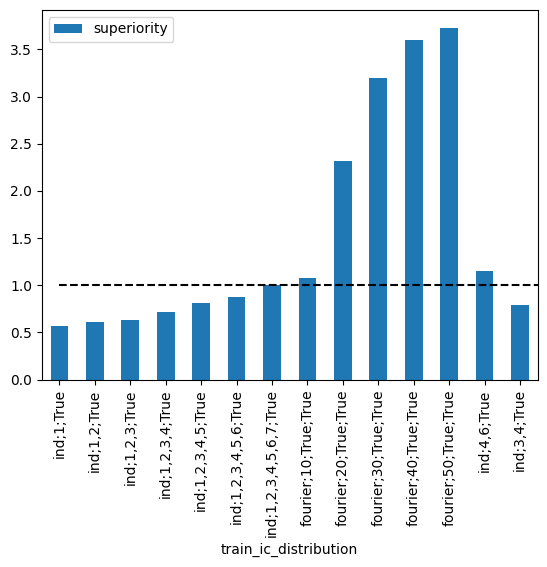

In [8]:
metrics.query("time_step == 1").plot.bar(
    x="train_ic_distribution",
    y="superiority",
)
plt.hlines(1.0, 0, len(configs), color="black", linestyle="--")

In [11]:
metrics.query("time_step == 1")[["train_ic_distribution", "superiority"]]

,train_ic_distribution,superiority
0,ind;1;True,0.568084
100,"ind;1,2;True",0.612017
200,"ind;1,2,3;True",0.635609
300,"ind;1,2,3,4;True",0.719470
400,"ind;1,2,3,4,5;True",0.812942
500,"ind;1,2,3,4,5,6;True",0.874815
600,"ind;1,2,3,4,5,6,7;True",1.007491
700,fourier;10;True;True,1.073589
800,fourier;20;True;True,2.319698
900,fourier;30;True;True,3.195764


In [13]:
print(
    metrics.query("time_step == 1")[["train_ic_distribution", "superiority"]].to_markdown(index=False)
)

| train_ic_distribution   |   superiority |
|:------------------------|--------------:|
| ind;1;True              |      0.568084 |
| ind;1,2;True            |      0.612017 |
| ind;1,2,3;True          |      0.635609 |
| ind;1,2,3,4;True        |      0.71947  |
| ind;1,2,3,4,5;True      |      0.812942 |
| ind;1,2,3,4,5,6;True    |      0.874815 |
| ind;1,2,3,4,5,6,7;True  |      1.00749  |
| fourier;10;True;True    |      1.07359  |
| fourier;20;True;True    |      2.3197   |
| fourier;30;True;True    |      3.19576  |
| fourier;40;True;True    |      3.60099  |
| fourier;50;True;True    |      3.73177  |
| ind;4,6;True            |      1.14687  |
| ind;3,4;True            |      0.790692 |
